In [1]:
import pandas as pd

In [ ]:
pip install pymysql

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import pymysql

In [ ]:
import pandas as pd

In [ ]:
print('hello')

hello


In [ ]:
db_config ={
    "host": "localhost",
    "user": "root",
    "password": "Sgk1@ggk",
    "database": "sales"
}

In [ ]:
queries = {
    "question1: Top 5 Products by Sales in 2022 for the 'Mobiles & Tablets' Category "
    "The Marketing Team is preparing for a Year-End Festival and needs to identify the top 5 products in the Mobiles & Tablets category that had the highest sales quantities in 2022.":
 """with product_sales as (SELECT 
        DATE_FORMAT(od.order_date, '%Y') AS year,
        sk.sku_name,
        sk.category,
        SUM(od.qty_ordered) AS total_qty
    FROM order_detail as od 
    join 
        sku_detail as sk on od.sku_id = sk.id 
    WHERE sk.category = 'Mobiles & Tablets'
        AND is_valid = 1
        AND DATE_FORMAT(od.order_date, '%Y') = 2022
    GROUP BY DATE_FORMAT(od.order_date, '%Y'), sk.sku_name, sk.category
    ),
    ranked_product as (
    select *,
    rank() over (order by total_qty desc) as sales_rank
	FROM product_sales )
    select  year,sku_name,
	    category,
        total_qty
	from ranked_product 
    where sales_rank <= 5 """
}

In [ ]:
from IPython.display import display

In [ ]:
#connect to the database
try:
    connection = pymysql.connect(**db_config)
    print("Database connection successful!")

    #excute each query
    for question, query in queries.items():
        print(f"\n--- {question} ---")
        df = pd.read_sql(query, connection)
        display(df) #display the dataframe in the notebook

except Exception as e: 
    print(f"an error occured: {e}")
finally:
    if connection:
        connection.close()
        print("database connection closed.")

Database connection successful!

--- question1: Top 5 Products by Sales in 2022 for the 'Mobiles & Tablets' Category The Marketing Team is preparing for a Year-End Festival and needs to identify the top 5 products in the Mobiles & Tablets category that had the highest sales quantities in 2022. ---


C:\Users\ABHISHEK\AppData\Local\Temp\ipykernel_2572\4176206804.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, connection)


,year,sku_name,category,total_qty
0,2022,IDROID_BALRX7-Gold,Mobiles & Tablets,1000.0
1,2022,IDROID_BALRX7-Jet black,Mobiles & Tablets,31.0
2,2022,Infinix Hot 4-Gold,Mobiles & Tablets,15.0
3,2022,samsung_Grand Prime Plus-Black,Mobiles & Tablets,11.0
4,2022,samsung_Grand Prime Plus-Silver,Mobiles & Tablets,10.0
5,2022,infinix_Zero 4-Grey,Mobiles & Tablets,10.0


database connection closed.


In [ ]:
import os

In [ ]:
#Folder path to save CSV files
output_folder = r"C:\Users\ABHISHEK\OneDrive\Desktop\internship\google looker\csv files" #replace with your folder path
os.makedirs(output_folder, exist_ok=True)  #create a folder if it doesnt exist

In [ ]:
#list of tables to export
tables = {"order_detail", "sku_detail", "payment_detail", "customer_detail"} #add your table names here

In [ ]:
try:
    #connect to the database 
    connection = pymysql.connect(**db_config)
    print("database conncetion successful")

    for table in tables:
        print(f"exporting table: {table}")

        #SQL query to fetch all data from the table
        query = f"SELECT * from {table};"

        #Read table data into a dataframe 
        df = pd.read_sql(query, connection)

        #save the dataframe to a csv file 
        output_file = os.path.join(output_folder, f"{table}.csv")
        df.to_csv(output_file, index = False)

        print(f"Table {table} exported successfully to {output_file}.")

except Exception as e:
    print(f"an error occured: {e}")
finally:
    if connection:
        connection.close()
        print("Database connection closed.")  

    

database conncetion successful
exporting table: payment_detail
Table payment_detail exported successfully to C:\Users\ABHISHEK\OneDrive\Desktop\internship\google looker\csv files\payment_detail.csv.
exporting table: sku_detail


C:\Users\ABHISHEK\AppData\Local\Temp\ipykernel_2572\2215843682.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, connection)


Table sku_detail exported successfully to C:\Users\ABHISHEK\OneDrive\Desktop\internship\google looker\csv files\sku_detail.csv.
exporting table: order_detail
Table order_detail exported successfully to C:\Users\ABHISHEK\OneDrive\Desktop\internship\google looker\csv files\order_detail.csv.
exporting table: customer_detail
Table customer_detail exported successfully to C:\Users\ABHISHEK\OneDrive\Desktop\internship\google looker\csv files\customer_detail.csv.
Database connection closed.


In [ ]:
df_od = pd.read_csv(r"C:\Users\ABHISHEK\OneDrive\Desktop\internship\google looker\csv files\order_detail.csv")
df_sd = pd.read_csv(r"C:\Users\ABHISHEK\OneDrive\Desktop\internship\google looker\csv files\sku_detail.csv")
df_pd = pd.read_csv(r"C:\Users\ABHISHEK\OneDrive\Desktop\internship\google looker\csv files\payment_detail.csv")
df_cd = pd.read_csv(r"C:\Users\ABHISHEK\OneDrive\Desktop\internship\google looker\csv files\customer_detail.csv")

In [ ]:
#Merge the dataframes
#Before merge we need to rename column in order to avoid duplicate column value
#so the key column will be excluded when joined 
df_sd.rename(columns = {'id':'sku_id'}, inplace = True)
df_cd.rename(columns = {'id':'customer_id'}, inplace = True)
df_pd.rename(columns = {'id':'payment_id'}, inplace = True)

In [ ]:
#Merge the dataframes using left join 
df = pd.DataFrame(df_od \
                  #merge orderdetail with sku_detail on column sku_id)
                  .merge(df_sd, how = 'left', on='sku_id') \
                  #merge the result to customer_detail on column customer_id 
                  .merge(df_cd, how = 'left', on = 'customer_id')\
                  #merge the result to payment_detail on column payment_id
                  .merge(df_pd, how = 'left', on = 'payment_id'))

In [ ]:
#check the dataframe information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5764 entries, 0 to 5763
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               5764 non-null   object 
 1   customer_id      5764 non-null   object 
 2   order_date       5764 non-null   object 
 3   sku_id           5764 non-null   object 
 4   price            5764 non-null   int64  
 5   qty_ordered      5764 non-null   int64  
 6   before_discount  5764 non-null   float64
 7   discount_amount  5764 non-null   float64
 8   after_discount   5764 non-null   float64
 9   is_gross         5764 non-null   int64  
 10  is_valid         5764 non-null   int64  
 11  is_net           5764 non-null   int64  
 12  payment_id       5764 non-null   int64  
 13  sku_name         5764 non-null   object 
 14  base_price       5764 non-null   float64
 15  cogs             5764 non-null   float64
 16  category         5764 non-null   object 
 17  registered_dat

In [ ]:
print(df_pd.columns)

Index(['payment_id', 'payment_method'], dtype='object')


In [ ]:
print(df_od.columns)

Index(['id', 'customer_id', 'order_date', 'sku_id', 'price', 'qty_ordered',
       'before_discount', 'discount_amount', 'after_discount', 'is_gross',
       'is_valid', 'is_net', 'payment_id'],
      dtype='object')


In [ ]:
print(df_cd.columns)

Index(['customer_id', 'registered_date'], dtype='object')


In [ ]:
print(df_sd.columns)

Index(['sku_id', 'sku_name', 'base_price', 'cogs', 'category'], dtype='object')


In [ ]:
#Ensure both columns have the same data type before merging
df_pd['payment_id'] = df_pd['payment_id'].astype(str) # convert to string 
df_od['id'] = df_od['id'].astype(str)

#merge order_detail with payment_detail without renaming columns 
df_sample = pd.merge(df_pd, df_od, how = 'left', left_on = 'payment_id', right_on = 'id')

# Display info about the resulting Dataframe 
df_sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   payment_id_x     16 non-null     object 
 1   payment_method   16 non-null     object 
 2   id               0 non-null      object 
 3   customer_id      0 non-null      object 
 4   order_date       0 non-null      object 
 5   sku_id           0 non-null      object 
 6   price            0 non-null      float64
 7   qty_ordered      0 non-null      float64
 8   before_discount  0 non-null      float64
 9   discount_amount  0 non-null      float64
 10  after_discount   0 non-null      float64
 11  is_gross         0 non-null      float64
 12  is_valid         0 non-null      float64
 13  is_net           0 non-null      float64
 14  payment_id_y     0 non-null      float64
dtypes: float64(9), object(6)
memory usage: 2.0+ KB


In [ ]:
# change columns to datetime format using for loop
# use pandas.to_datetime to convert

for x in ['order_date', 'registered_date']:
    df[x] = pd.to_datetime(df[x])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5764 entries, 0 to 5763
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id               5764 non-null   object        
 1   customer_id      5764 non-null   object        
 2   order_date       5764 non-null   datetime64[ns]
 3   sku_id           5764 non-null   object        
 4   price            5764 non-null   int64         
 5   qty_ordered      5764 non-null   int64         
 6   before_discount  5764 non-null   float64       
 7   discount_amount  5764 non-null   float64       
 8   after_discount   5764 non-null   float64       
 9   is_gross         5764 non-null   int64         
 10  is_valid         5764 non-null   int64         
 11  is_net           5764 non-null   int64         
 12  payment_id       5764 non-null   int64         
 13  sku_name         5764 non-null   object        
 14  base_price       5764 non-null   float64

In [ ]:
top_5_prod =pd.DataFrame(\
                          #filter the columns as needed
                          df[(df['category']=='Mobiles & Tablets') & (df['is_valid']==1) & (df['order_date'].dt.year== 2022)]\
                        # aggregate using groupby method 
                        .groupby(by = ['sku_name', 'category'])['qty_ordered'].sum()\
                        #reset the index to convert result into dataframe 
                        .reset_index(name = 'qty_ordered')\
                        #sort the valuefrom the largest to the lowest
                        .sort_values(by= 'qty_ordered', ascending = False)\
                        # select top 5 row
                        .head(5).reset_index(drop = True)
                            )

top_5_prod

,sku_name,category,qty_ordered
0,IDROID_BALRX7-Gold,Mobiles & Tablets,1000
1,IDROID_BALRX7-Jet black,Mobiles & Tablets,31
2,Infinix Hot 4-Gold,Mobiles & Tablets,15
3,samsung_Grand Prime Plus-Black,Mobiles & Tablets,11
4,infinix_Zero 4-Grey,Mobiles & Tablets,10


In [ ]:
!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


<Axes: title={'center': 'TOP_5_PRODUCTS'}, xlabel='quantity', ylabel='product_name'>

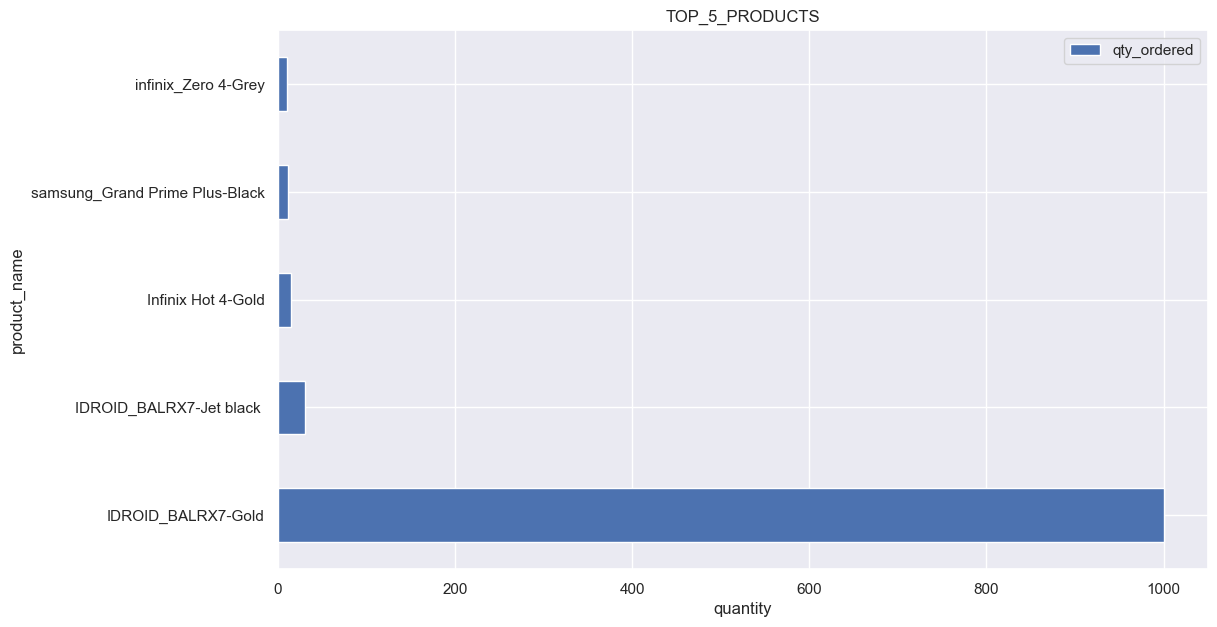

In [ ]:
# show the chart
import seaborn as sns
#plot 
sns.set()
top_5_prod.plot(x='sku_name',
                y= ['qty_ordered'],
                kind='barh',
                grid = True,
                xlabel = 'quantity',
                ylabel= 'product_name',
                figsize=(12,7),
                rot=0,
                title= 'TOP_5_PRODUCTS',
                table=False,
                secondary_y= False)


In [ ]:
"""Question 2- 
Average Quantity Sold per Product by Category Scenario: The Product Team wants to know the average quantity sold for each product category to identify potential inventory issues. 
Requirements: • Create a bar chart that shows the average quantity sold (AVG(qty_ordered)) for each product category. 
• Sort the categories by average quantity sold in descending order. Key Features to Use: • category • qty_ordered"""

'Question 2- \nAverage Quantity Sold per Product by Category Scenario: The Product Team wants to know the average quantity sold for each product category to identify potential inventory issues. \nRequirements: • Create a bar chart that shows the average quantity sold (AVG(qty_ordered)) for each product category. \n• Sort the categories by average quantity sold in descending order. Key Features to Use: • category • qty_ordered'

In [ ]:
queries = {
    "Average Quantity Sold per Category": """
    SELECT sk.category,
           AVG(od.qty_ordered) AS avg_qty_sold
    FROM order_detail od
    JOIN sku_detail sk ON od.sku_id = sk.id
    GROUP BY sk.category
    ORDER BY avg_qty_sold DESC;
    """
}

In [ ]:
import pymysql
import pandas as pd

connection = pymysql.connect(**db_config)

query = """
    SELECT sk.category,
           AVG(od.qty_ordered) AS avg_qty_sold
    FROM order_detail od
    JOIN sku_detail sk ON od.sku_id = sk.id
    GROUP BY sk.category
    ORDER BY avg_qty_sold DESC;"""

df = pd.read_sql(query, connection)
display(df)

connection.close()




C:\Users\ABHISHEK\AppData\Local\Temp\ipykernel_2572\4260927943.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, connection)


,category,avg_qty_sold
0,Mobiles & Tablets,6.7940
1,Soghaat,5.9375
2,Superstore,3.4521
3,Women Fashion,2.1022
4,Others,2.0403
5,Men Fashion,2.0302
6,Beauty & Grooming,1.5558
7,Books,1.4441
8,Home & Living,1.4035
9,School & Education,1.3429


In [ ]:
with pymysql.connect(**db_config) as connection:
    Avg_qty_sold = pd.read_sql(query, connection)
    display(Avg_qty_sold)

C:\Users\ABHISHEK\AppData\Local\Temp\ipykernel_2572\1886585490.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  Avg_qty_sold = pd.read_sql(query, connection)


,category,avg_qty_sold
0,Mobiles & Tablets,6.7940
1,Soghaat,5.9375
2,Superstore,3.4521
3,Women Fashion,2.1022
4,Others,2.0403
5,Men Fashion,2.0302
6,Beauty & Grooming,1.5558
7,Books,1.4441
8,Home & Living,1.4035
9,School & Education,1.3429


<Axes: title={'center': 'Average_quantity_sold'}, xlabel='category', ylabel='quantity_ordered'>

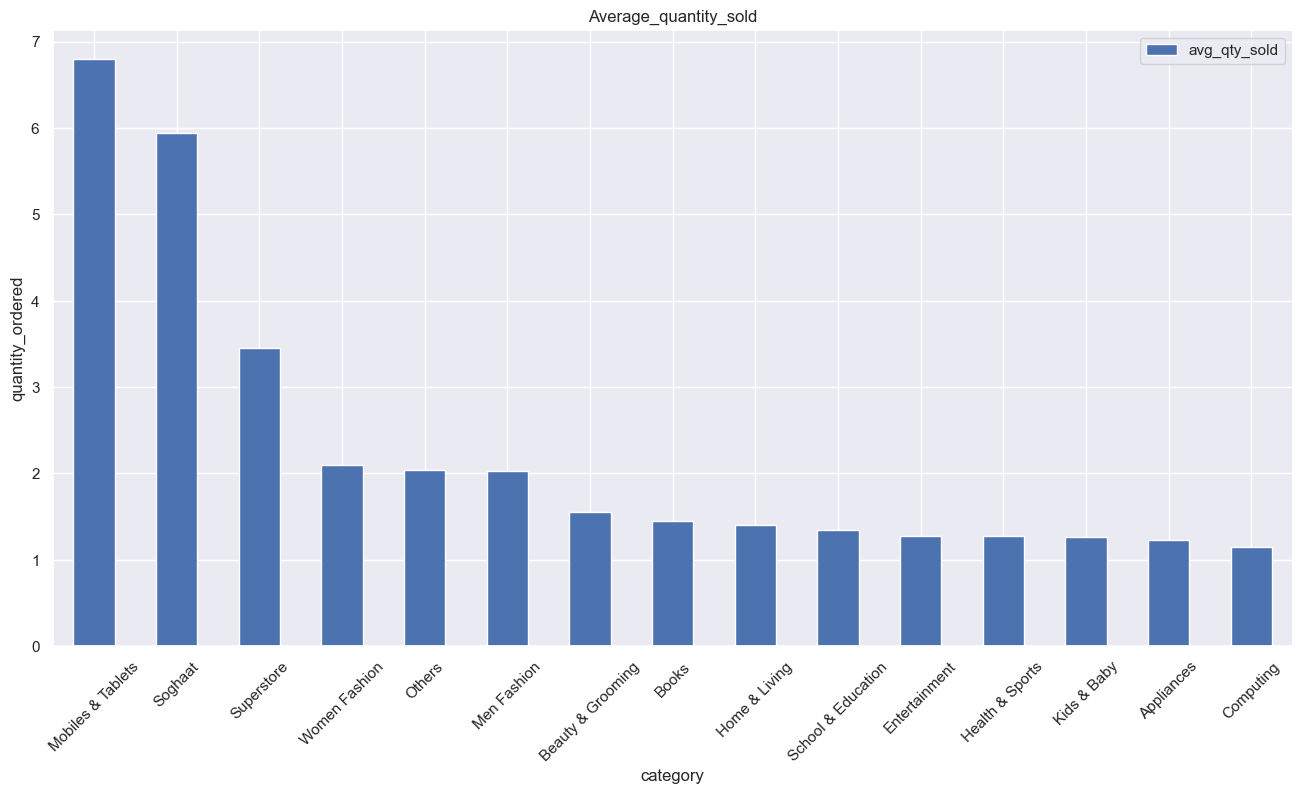

In [ ]:
 #show the chart
import seaborn as sns
#plot 
sns.set()
Avg_qty_sold.plot(x='category',
                y= ['avg_qty_sold'],
                kind='bar',
                grid = True,
                xlabel = 'category',
                ylabel= 'quantity_ordered',
                figsize=(16,8),
                rot=45,
                title= 'Average_quantity_sold',
                table=False,
                secondary_y= False)

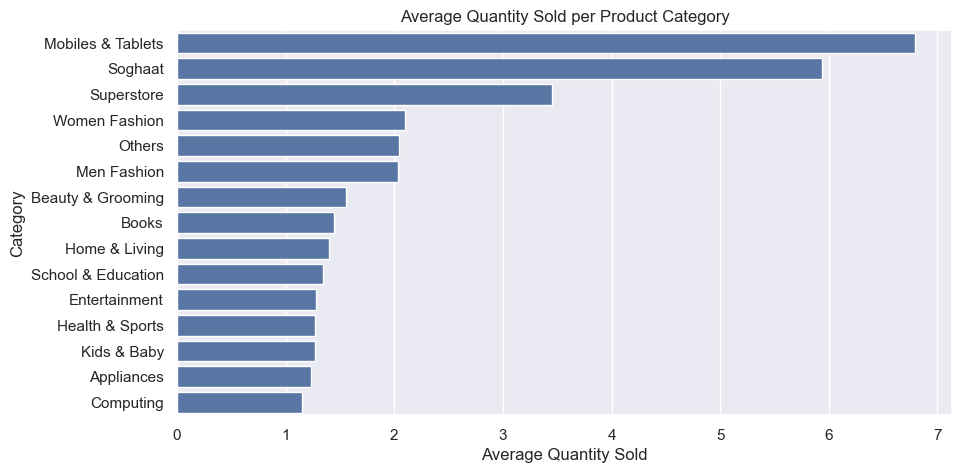

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sort again (safe)
df = df.sort_values('avg_qty_sold', ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x="avg_qty_sold", y="category", data=df)
plt.title("Average Quantity Sold per Product Category")
plt.xlabel("Average Quantity Sold")
plt.ylabel("Category")
plt.show()

In [ ]:
'''Question 3: Product Category Performance by Net Profit Scenario: The Operations 
Team wants to analyze the net profit for each product category to identify the most profitable categories.'''

'Question 3: Product Category Performance by Net Profit Scenario: The Operations \nTeam wants to analyze the net profit for each product category to identify the most profitable categories.'

In [ ]:
print(df_od.columns)
print(df_sd.columns)

Index(['id', 'customer_id', 'order_date', 'sku_id', 'price', 'qty_ordered',
       'before_discount', 'discount_amount', 'after_discount', 'is_gross',
       'is_valid', 'is_net', 'payment_id'],
      dtype='object')
Index(['sku_id', 'sku_name', 'base_price', 'cogs', 'category'], dtype='object')


In [ ]:
import pymysql
import pandas as pd

connection = pymysql.connect(**db_config)
print("Reconnected to database")

Reconnected to database


In [ ]:
print(df.columns)

Index(['category', 'avg_qty_sold'], dtype='object')


In [ ]:
df = pd.read_sql("SELECT * FROM sku_detail", connection)

C:\Users\ABHISHEK\AppData\Local\Temp\ipykernel_2572\174291827.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM sku_detail", connection)


In [ ]:
df = pd.read_sql("SELECT * FROM order_detail", connection)

C:\Users\ABHISHEK\AppData\Local\Temp\ipykernel_2572\300988214.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM order_detail", connection)


In [ ]:
print(df.columns)

Index(['id', 'customer_id', 'order_date', 'sku_id', 'price', 'qty_ordered',
       'before_discount', 'discount_amount', 'after_discount', 'is_gross',
       'is_valid', 'is_net', 'payment_id'],
      dtype='object')


In [ ]:
print(df_sd.columns)
print(df_od.columns)

Index(['sku_id', 'sku_name', 'base_price', 'cogs', 'category'], dtype='object')
Index(['id', 'customer_id', 'order_date', 'sku_id', 'price', 'qty_ordered',
       'before_discount', 'discount_amount', 'after_discount', 'is_gross',
       'is_valid', 'is_net', 'payment_id'],
      dtype='object')


In [ ]:
#merge the tables 

df = df_od.merge(df_sd, left_on='sku_id', right_on ='sku_id', how='inner')

In [ ]:
df['net_profit'] = df['after_discount'] - df['cogs']

In [ ]:
net_profit=df['net_profit']

In [ ]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['year'] = df['order_date'].dt.year

In [ ]:
print(df.columns)

Index(['id', 'customer_id', 'order_date', 'sku_id', 'price', 'qty_ordered',
       'before_discount', 'discount_amount', 'after_discount', 'is_gross',
       'is_valid', 'is_net', 'payment_id', 'sku_name', 'base_price', 'cogs',
       'category', 'net_profit', 'year'],
      dtype='object')


In [ ]:
year_selected = 2021
filtered_df = df[df['year'] == year_selected]

In [ ]:
profit_by_category = (
   filtered_df.groupby('category')['net_profit'] .sum() 
   .reset_index()
    .sort_values(by='net_profit', ascending=False)
    .reset_index(drop=True)
   
)

In [ ]:
print("Available years:", df['year'].dropna().unique())

Available years: [2022 2021]


In [ ]:
profit_by_category

,category,net_profit
0,Mobiles & Tablets,625487880.0
1,Computing,210109748.0
2,Entertainment,193726224.0
3,Appliances,159568414.0
4,Women Fashion,41819489.4
5,Men Fashion,36643758.0
6,Home & Living,35650654.0
7,Others,27943292.2
8,Beauty & Grooming,26075120.0
9,Superstore,21624498.0


In [ ]:
df.columns

Index(['id', 'customer_id', 'order_date', 'sku_id', 'price', 'qty_ordered',
       'before_discount', 'discount_amount', 'after_discount', 'is_gross',
       'is_valid', 'is_net', 'payment_id', 'sku_name', 'base_price', 'cogs',
       'category', 'net_profit', 'year'],
      dtype='object')

<Axes: title={'center': 'profit_by_category'}, xlabel='category', ylabel='net_profit'>

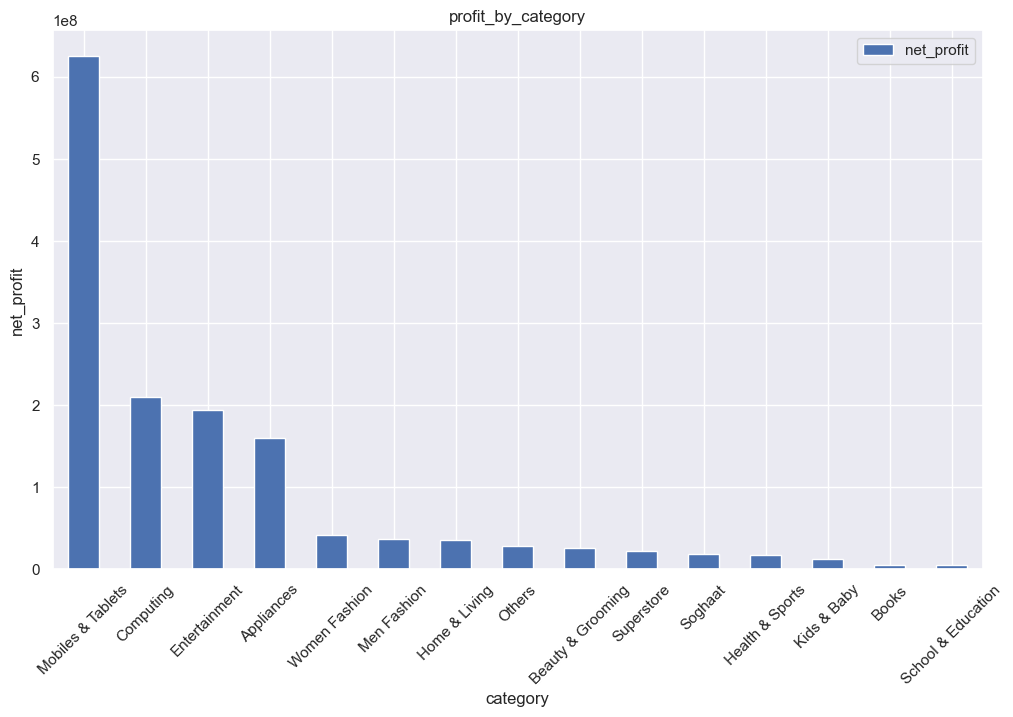

In [ ]:
 import seaborn as sns
#plot 
sns.set()
df = df.sort_values("net_profit", ascending=False)
profit_by_category.plot(x='category',
                y= ['net_profit'],
                kind='bar',
                grid = True,
                xlabel = 'category',
                ylabel= 'net_profit',
                figsize=(12,7),
                rot=45,
                title= 'profit_by_category',
                table=False,
                secondary_y= False)

In [ ]:
'''Question 4:Comparing Sales Trends for Multiple Categories in 2022 Scenario: 
    The Marketing Team wants to compare the sales trends for multiple categories in 2022 to identify which category performed best. 
    Requirements: 1. Aggregate the sales data by category for 2022. 
    2. Plot a time series of sales trends for each category (use order_date to group by month or week).
    3. Provide insights on which category had the highest sales growth. Key Features to Use: • category • order_date (for time series analysis) • qty_ordered'''


'Question 4:Comparing Sales Trends for Multiple Categories in 2022 Scenario: \n    The Marketing Team wants to compare the sales trends for multiple categories in 2022 to identify which category performed best. \n    Requirements: 1. Aggregate the sales data by category for 2022. \n    2. Plot a time series of sales trends for each category (use order_date to group by month or week).\n    3. Provide insights on which category had the highest sales growth. Key Features to Use: • category • order_date (for time series analysis) • qty_ordered'

In [ ]:
df = pd.merge(df_od, df_sd, on="sku_id", how="left")

In [ ]:
# convert to datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# filter only 2022
df_2022 = df[df['order_date'].dt.year == 2022]

# reset index
df_2022 = df_2022.reset_index(drop=True)

df_2022.head()

,id,customer_id,order_date,sku_id,price,qty_ordered,before_discount,discount_amount,after_discount,is_gross,is_valid,is_net,payment_id,sku_name,base_price,cogs,category
0,ODR1111336599a,C993531L,2022-02-23,P569750,62002,1,62002.0,0.0,62002.0,1,0,0,5,emart_Magic Hose Pipe 75 Ft,61654.0,51156.0,Home & Living
1,ODR1116457650x,C517907L,2022-10-08,P320550,159500,1,159500.0,0.0,159500.0,1,1,1,1,sheraton_FMOTORS_01,159500.0,97266.0,Health & Sports
2,ODR1126180881t,C875194L,2022-01-14,P507387,57420,2,114840.0,0.0,114840.0,1,1,0,1,nutrifactor_NF002,57420.0,51098.0,Health & Sports
3,ODR1129414841e,C652751L,2022-07-26,P392301,4756000,1,4756000.0,0.0,4756000.0,1,0,0,1,Ifitness_T300,4756000.0,3757240.0,Health & Sports
4,ODR1131384330p,C597119L,2022-04-16,P920137,28942,3,86826.0,0.0,86826.0,1,1,1,1,emart_0-64,14500.0,11716.0,Home & Living


In [ ]:
df_2022['month'] = df_2022['order_date'].dt.to_period('M').dt.to_timestamp()

monthly_sales = (
    df_2022
    .groupby(['month', 'category'])['qty_ordered']
    .sum()
    .reset_index()
)

monthly_sales.head()

,month,category,qty_ordered
0,2022-01-01,Appliances,30
1,2022-01-01,Beauty & Grooming,57
2,2022-01-01,Books,35
3,2022-01-01,Computing,27
4,2022-01-01,Entertainment,27


In [ ]:
pivot_df = monthly_sales.pivot(
    index='month',
    columns='category',
    values='qty_ordered'
)



In [ ]:
pivot_df = pivot_df.sort_index()
pivot_df.head()

category,Appliances,Beauty & Grooming,Books,Computing,Entertainment,Health & Sports,Home & Living,Kids & Baby,Men Fashion,Mobiles & Tablets,Others,School & Education,Soghaat,Superstore,Women Fashion
month,,,,,,,,,,,,,,,
2022-01-01,30,57,35,27,27,36,34,37,66,58,32,54,127,116,33
2022-02-01,34,25,19,28,24,25,34,24,33,55,34,26,144,76,29
2022-03-01,33,27,30,28,31,31,41,41,32,53,39,33,117,101,197
2022-04-01,29,44,22,30,73,29,52,30,29,49,30,24,394,111,181
2022-05-01,26,30,25,28,26,31,30,41,67,32,36,25,180,46,36


<Figure size 1200x600 with 0 Axes>

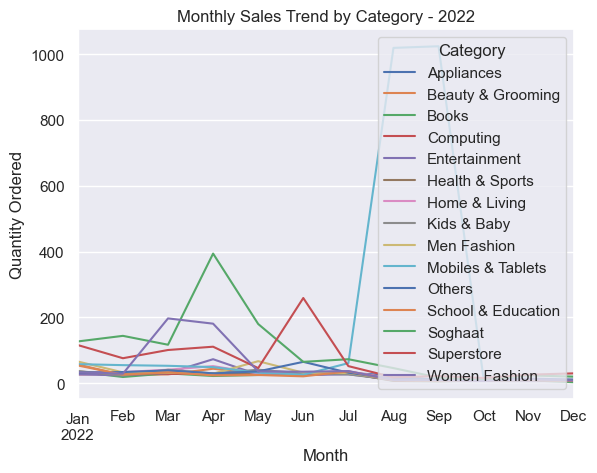

In [ ]:
plt.figure(figsize=(12,6))
pivot_df.plot()

plt.title("Monthly Sales Trend by Category - 2022")
plt.xlabel("Month")
plt.ylabel("Quantity Ordered")
plt.legend(title="Category")
plt.grid(True)
plt.show()

In [ ]:
growth = pivot_df.iloc[-1] - pivot_df.iloc[0]
growth_percent = (growth / pivot_df.iloc[0]) * 100

growth_df = pd.DataFrame({
    "Absolute Growth": growth,
    "Growth %": growth_percent
}).sort_values(by="Growth %", ascending=False)

growth_df

,Absolute Growth,Growth %
category,,
Others,-21,-65.625000
Appliances,-21,-70.000000
Entertainment,-19,-70.370370
Computing,-19,-70.370370
Home & Living,-24,-70.588235
Kids & Baby,-27,-72.972973
Superstore,-86,-74.137931
Women Fashion,-25,-75.757576
Health & Sports,-28,-77.777778


In [ ]:
best_category = growth_df.index[0]
best_growth = growth_df.iloc[0]["Growth %"]

print(f"Best performing category in 2022: {best_category}")
print(f"Growth percentage: {best_growth:.2f}%")

Best performing category in 2022: Others
Growth percentage: -65.62%


In [ ]:
'''Finding Products with the Largest Decrease in Sales Between Two Periods (e.g., 2022 vs 2021) Scenario: 
The Sales Team would like to identify which products had the most significant decrease in sales between two periods (e.g., 2021 and 2022). 
Requirements: 1. Create two datasets for each period (e.g., 2021 and 2022), aggregated by product (sku_name). 
2. Calculate the sales difference between the two periods. 3. Identify the products with the largest decrease in sales and show the top 10 products. 
4. Create a bar chart to visualize the products with the largest decrease in sales. Key Features to Use: 
• sku_name (for product names) • order_date (for filtering by year) • qty_ordered (for sales data)'''

'Finding Products with the Largest Decrease in Sales Between Two Periods (e.g., 2022 vs 2021) Scenario: \nThe Sales Team would like to identify which products had the most significant decrease in sales between two periods (e.g., 2021 and 2022). \nRequirements: 1. Create two datasets for each period (e.g., 2021 and 2022), aggregated by product (sku_name). \n2. Calculate the sales difference between the two periods. 3. Identify the products with the largest decrease in sales and show the top 10 products. \n4. Create a bar chart to visualize the products with the largest decrease in sales. Key Features to Use: \n• sku_name (for product names) • order_date (for filtering by year) • qty_ordered (for sales data)'

In [ ]:
df.columns

Index(['id', 'customer_id', 'order_date', 'sku_id', 'price', 'qty_ordered',
       'before_discount', 'discount_amount', 'after_discount', 'is_gross',
       'is_valid', 'is_net', 'payment_id', 'sku_name', 'base_price', 'cogs',
       'category'],
      dtype='object')

In [ ]:
print(df['order_date'].dtype)

datetime64[ns]


In [ ]:
df['order_date'] = pd.to_datetime(df['order_date'])

In [ ]:
df['year'] = df['order_date'].dt.year

In [ ]:
print(df[['order_date','year']].head())

  order_date  year
0 2022-02-23  2022
1 2022-10-08  2022
2 2021-08-07  2021
3 2021-08-11  2021
4 2021-09-18  2021


In [ ]:
print(df['order_date'].value_counts())

order_date
2022-01-29    15
2021-09-28    15
2022-10-08    15
2021-06-08    15
2021-11-19    15
              ..
2021-11-07    12
2021-03-07    11
2022-06-26    11
2022-06-27    11
2021-09-13    10
Name: count, Length: 409, dtype: int64


In [ ]:
sales_2021 = (
    df[df['year'] == 2021]
    .groupby('sku_name')['qty_ordered']
    .sum()
    .reset_index(name='sales_2021')
)

sales_2022 = (
    df[df['year'] == 2022]
    .groupby('sku_name')['qty_ordered']
    .sum()
    .reset_index(name='sales_2022')
)

In [ ]:
sales_compare = sales_2021.merge(sales_2022, on='sku_name', how='outer').fillna(0)

sales_compare['sales_change'] = (
    sales_compare['sales_2022'] - sales_compare['sales_2021']
)

In [ ]:
top_decrease = sales_compare.sort_values('sales_change').head(10)

print(top_decrease)

                                               sku_name  sales_2021  \
2911         shahi_buy one get one free Shahi Dal Moong       240.0   
1492                                      RS_Plain Rusk       160.0   
1448                      RB_Dettol Germ Busting Kit-bf       200.0   
1451                                RB_Household Bundle       133.0   
396                     CK_BF530-Underwear-Pack of 3-XL       119.0   
3110  vitamin_TVC-BB Cream (Buy 2 Get Kojic Facewash...        99.0   
1480                                   RS_Baklawa 500gm       107.0   
1486                           RS_Honey Dry Fruit Halwa        52.0   
377                                      CA_shirt-Small        50.0   
2523                                            jn_900g        57.0   

      sales_2022  sales_change  
2911         0.0        -240.0  
1492         0.0        -160.0  
1448        45.0        -155.0  
1451         0.0        -133.0  
396          0.0        -119.0  
3110         0.0    

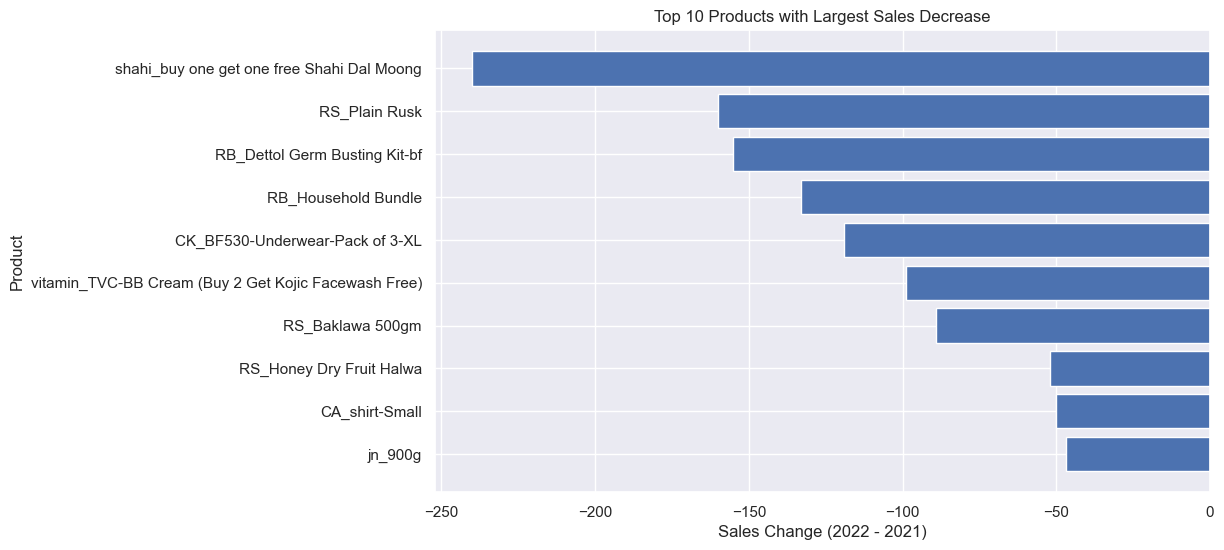

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(top_decrease['sku_name'], top_decrease['sales_change'])
plt.xlabel("Sales Change (2022 - 2021)")
plt.ylabel("Product")
plt.title("Top 10 Products with Largest Sales Decrease")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
'''Comparing Weekend and Weekday Sales in Q4 2022 Scenario: 
The Campaign Team wants to evaluate the effectiveness of their weekend promotional campaigns (Saturdays and Sundays) between October and December 2022 
by comparing the average daily sales during weekends vs weekdays. Requirements:
 1. Calculate the average daily sales (before_discount) for weekends (Saturdays and Sundays) and weekdays (Monday to Friday) for each month 
 (October, November, and December 2022). 2. Calculate the average sales for weekends vs weekdays for the entire three-month period.
 3. Share insights on whether sales increased during weekends. Key Features to Use:
 • order_date (for filtering by date and identifying days of the week) • before_discount (for sales data) 
 • month_id, month_name, day_name, year (for extracting date-related information)'''

'Comparing Weekend and Weekday Sales in Q4 2022 Scenario: \nThe Campaign Team wants to evaluate the effectiveness of their weekend promotional campaigns (Saturdays and Sundays) between October and December 2022 \nby comparing the average daily sales during weekends vs weekdays. Requirements:\n 1. Calculate the average daily sales (before_discount) for weekends (Saturdays and Sundays) and weekdays (Monday to Friday) for each month \n (October, November, and December 2022). 2. Calculate the average sales for weekends vs weekdays for the entire three-month period.\n 3. Share insights on whether sales increased during weekends. Key Features to Use:\n • order_date (for filtering by date and identifying days of the week) • before_discount (for sales data) \n • month_id, month_name, day_name, year (for extracting date-related information)'

In [ ]:
import pandas as pd

In [ ]:
df_od['order_date'] = pd.to_datetime(df_od['order_date'])


In [ ]:
df.columns

Index(['id', 'customer_id', 'order_date', 'sku_id', 'price', 'qty_ordered',
       'before_discount', 'discount_amount', 'after_discount', 'is_gross',
       'is_valid', 'is_net', 'payment_id', 'sku_name', 'base_price', 'cogs',
       'category', 'year'],
      dtype='object')

In [ ]:
print(df_od['payment_id'].dtype)
print(df_pd['payment_id'].dtype)

int64
object


In [ ]:
df_od['payment_id'] = df_od['payment_id'].astype(int)
df_pd['payment_id'] = df_pd['payment_id'].astype(int)

In [ ]:
df = df_od.merge(df_cd, on='customer_id', how='left') \
                 .merge(df_sd, on='sku_id', how='left') \
                 .merge(df_pd, on='payment_id', how='left')

In [ ]:
q4 = df[
    (df['order_date'].dt.year == 2022) &
    (df['order_date'].dt.month.isin([10, 11, 12]))
].copy()

In [ ]:
q4['month_name'] = q4['order_date'].dt.month_name()
q4['day_name'] = q4['order_date'].dt.day_name()

q4['day_type'] = q4['day_name'].apply(
    lambda x: 'Weekend' if x in ['Saturday', 'Sunday'] else 'Weekday'
)

In [ ]:
monthly_avg = (
    q4.groupby(['month_name', 'day_type'])['before_discount']
    .mean()
    .reset_index()
    .sort_values(['month_name', 'day_type'])
)

monthly_avg

,month_name,day_type,before_discount
0,December,Weekday,9.632348e+05
1,December,Weekend,1.008580e+06
2,November,Weekday,1.287936e+06
3,November,Weekend,1.046216e+06
4,October,Weekday,1.149573e+06
5,October,Weekend,9.971162e+05


In [ ]:
overall_avg = (
    q4.groupby('day_type')['before_discount']
    .mean()
    .reset_index()
)

overall_avg

,day_type,before_discount
0,Weekday,1.135207e+06
1,Weekend,1.014335e+06


In [ ]:
weekend_avg = overall_avg.loc[overall_avg['day_type']=='Weekend','before_discount'].values[0]
weekday_avg = overall_avg.loc[overall_avg['day_type']=='Weekday','before_discount'].values[0]

percent_diff = ((weekend_avg - weekday_avg) / weekday_avg) * 100

print(f"Weekend sales are {percent_diff:.2f}% higher than weekday sales in Q4 2022.")

Weekend sales are -10.65% higher than weekday sales in Q4 2022.


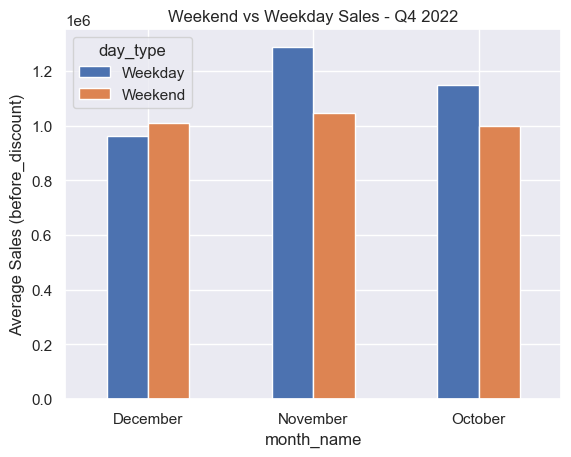

In [ ]:
import matplotlib.pyplot as plt

monthly_avg.pivot(index='month_name', columns='day_type', values='before_discount').plot(kind='bar')
plt.title("Weekend vs Weekday Sales - Q4 2022")
plt.ylabel("Average Sales (before_discount)")
plt.xticks(rotation=0)
plt.show()

In [ ]:
#SPECIFY THE FILE PATH
file_path = r"D:\elevance project\google_looker\final_dataset.csv"

#save to csv file 
df.to_csv(file_path, index=False)
print(f"file sucessfully saved to {file_path}")

file sucessfully saved to D:\elevance project\google_looker\final_dataset.csv


In [2]:
git --version

NameError: name 'git' is not defined